In [1]:
import os
import sys
sys.path.append('src/FoKL')

import FoKLRoutines
import numpy as np


Currently training model...

Processing ind=1, entropy_level=0 (entropy=0.000)
[1, 0, -766.2291688996959]
Processing ind=2, entropy_level=0 (entropy=1.000)
[2, 0, -979.7976209289562]
Processing ind=2, entropy_level=1 (entropy=0.000)
[2, 1, -1073.0620143972403]
Processing ind=3, entropy_level=0 (entropy=0.918)
[3, 0, -1153.1732874144154]
Processing ind=3, entropy_level=1 (entropy=0.000)
[3, 1, -1164.429981776186]
Processing ind=4, entropy_level=0 (entropy=1.000)
[4, 0, -1146.320038778629]
Processing ind=4, entropy_level=1 (entropy=0.811)
[4, 1, -1208.0557099859927]
Processing ind=4, entropy_level=2 (entropy=0.000)
[4, 2, -1288.5609468547066]
Processing ind=5, entropy_level=0 (entropy=0.971)
[5, 0, -1281.3809602710537]
Processing ind=5, entropy_level=1 (entropy=0.722)
[5, 1, -1360.55798120385]
Processing ind=5, entropy_level=2 (entropy=0.000)
[5, 2, -1464.8902066162436]
Processing ind=6, entropy_level=0 (entropy=1.000)
[6, 0, -1448.3241385291344]
Processing ind=6, entropy_level=1 (entro

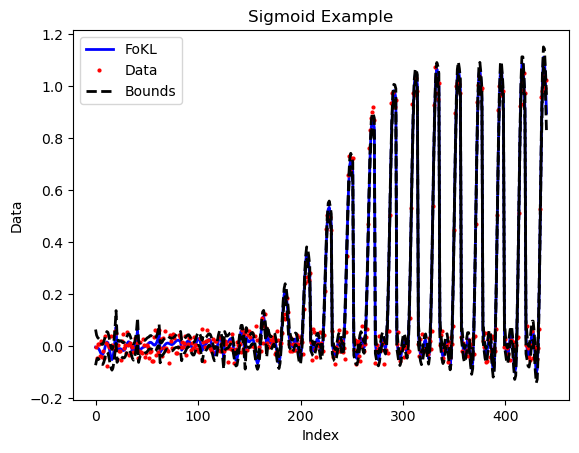


The 'coverage3' method returned:
    RMSE = 3.5926189701921335e-05


In [2]:
# Known dataset:
x_grid = np.loadtxt('src/FoKL/x.csv', dtype=float, delimiter=',')  # first input
y_grid = np.loadtxt('src/FoKL/y.csv', dtype=float, delimiter=',')  # second input
z_grid = np.loadtxt('src/FoKL/z.csv', dtype=float, delimiter=',')  # data

# Some formatting of dataset (i.e., reshaping grid matrices into vectors via fortran index order):
m, n = np.shape(x_grid) # == np.shape(y_grid) == np.shape(z_grid) == dimensions of grid
x = np.reshape(x_grid, (m * n, 1), order='F')
y = np.reshape(y_grid, (m * n, 1), order='F')
z = np.reshape(z_grid, (m * n, 1), order='F')

# Initializing FoKL model with some user-defined hyperparameters (leaving others blank for default values) and
# turning off user-warnings (i.e., warnings from FoKL) since working example requires no troubleshooting:
model = FoKLRoutines.FoKL(a=9, b=0.01, atau=3, btau=4000, aic=False, UserWarnings=False)

# Running emulator routine (i.e., 'fit') to train model:
print("\nCurrently training model...\n")
betas, mtx, ev = model.fit([x, y], z, clean=True)

# Evaluating and visualizing predicted values of data as a function of all inputs (train set plus test set):
print("\nDone! Please close the figure to continue.")
_, _, rmse = model.coverage3(plot=True, title='Sigmoid Example')

# Post-processing:
print(f"\nThe 'coverage3' method returned:\n    RMSE = {rmse}")

In [3]:
mtx

array([[0, 1],
       [1, 0],
       [1, 1],
       [0, 2],
       [2, 0],
       [1, 2],
       [2, 1],
       [3, 0],
       [2, 2],
       [3, 1],
       [0, 4],
       [4, 0],
       [3, 2],
       [1, 4],
       [4, 1],
       [0, 5],
       [5, 0],
       [3, 3],
       [1, 5],
       [5, 1]])

In [4]:
import numpy as np
import itertools

def perms(x):
    """
    Generates all unique permutations of the elements in a 1D array.

    This function is a Python equivalent of MATLAB's 'perms' function,
    but it also ensures that only unique permutations are returned.

    Args:
        x (np.ndarray): A 1D NumPy array whose elements will be permuted.

    Returns:
        np.ndarray: A 2D NumPy array where each row is a unique permutation
                    of the input array 'x'. The rows are reversed compared
                    to the default itertools.permutations order.
    """
    # Generate all permutations as tuples
    all_permutations = list(itertools.permutations(x))

    # Stack them vertically into a NumPy array
    # np.unique with axis=0 removes duplicate rows
    # [::-1] reverses the order of the rows
    unique_permutations = np.unique(np.vstack(all_permutations), axis=0)[::-1]
    return unique_permutations

def _get_integer_partitions_fixed_parts(n, k):
    """
    Recursively generates all unique partitions of integer n into k non-negative parts.
    The order of parts within a partition does not matter (e.g., [1,2] is same as [2,1]).
    Returns partitions as lists of integers, sorted in descending order to ensure uniqueness
    of the base partition.

    Args:
        n (int): The integer to partition.
        k (int): The fixed number of parts.

    Returns:
        list of list of int: A list where each element is a unique partition
                              of n into k parts, with parts sorted descending.
    """
    if k == 0:
        return [[]] if n == 0 else []
    if k == 1:
        return [[n]]

    partitions = set()
    # Iterate through possible values for the first part
    for i in range(n + 1):
        # Recursively find partitions for the remaining sum (n-i) into (k-1) parts
        for p in _get_integer_partitions_fixed_parts(n - i, k - 1):
            # Form the full partition, sort it descending to ensure uniqueness of the set
            # (e.g., (1,2,0) and (2,1,0) both become (2,1,0) before adding to set)
            partitions.add(tuple(sorted([i] + p, reverse=True)))
    return [list(p) for p in partitions]


def generate_interaction_matrix(m, ind, relats):
    """
    Generates and filters combinations of integer exponents for polynomial
    regression interaction terms, forming an interaction matrix.

    This function generates all possible unique combinations of 'm' non-negative
    integer exponents that sum up to 'ind', and then filters them based on
    predefined relationships (relats).

    Args:
        m (int): The number of input variables (e.g., features in a model).
                 This determines the length of the exponent vectors.
        ind (int): The target sum for the exponents in each combination.
                   This represents the 'degree' or 'order' of interaction
                   being considered (e.g., ind=2 for quadratic terms or
                   two-way interactions).
        relats (np.ndarray): A 2D NumPy array containing 'relation' patterns.
                             Each row is a binary vector (1s and 0s) that
                             represents a forbidden or redundant pattern of
                             active variables. If an interaction term's
                             active variable pattern matches a row in 'relats',
                             that term is filtered out. If 'relats' is empty,
                             no filtering is performed.

    Returns:
        np.ndarray: A 2D NumPy array (the 'interaction matrix' for this
                    particular 'ind' value). Each row represents a unique
                    and allowed combination of exponents for the 'm' input
                    variables that sum up to 'ind'. Returns an empty array
                    if no valid combinations are found after filtering.
    """
    # 1. Generate all unique base partitions of 'ind' into 'm' parts.
    # Each partition is a unique set of exponents that sum to 'ind'.
    # Example: for ind=4, m=3, this might return [[4,0,0], [3,1,0], [2,2,0], [2,1,1]]
    base_partitions = _get_integer_partitions_fixed_parts(ind, m)

    all_permutations_combined = []
    # 2. For each base partition, generate all its unique permutations.
    # These permutations represent all possible ways to assign the exponents
    # from that partition to the 'm' input variables.
    for partition_vec_list in base_partitions:
        partition_vec_np = np.array(partition_vec_list, dtype=int)
        # Get unique permutations for this specific partition
        current_permutations = perms(partition_vec_np)
        all_permutations_combined.append(current_permutations)

    if not all_permutations_combined:
        # If no partitions were generated, return an empty array of the correct shape
        return np.array([], dtype=int).reshape(0, m)

    # Combine all permutations and ensure overall uniqueness across all partitions
    vecs = np.unique(np.vstack(all_permutations_combined), axis=0)

    # Determine dimensions of vecs (still needed for subsequent loops)
    mvec, nvec = np.shape(vecs) # nvec will always be 'm' here

    kill_indices = [] # List to store indices of vectors to be removed

    # 3. Filter permutations based on 'relats'
    # This step removes terms that match predefined 'forbidden' patterns.
    num_relations = relats.shape[0] # Inferred number of relations
    if num_relations != 0: # Only filter if there are relation patterns
        for j in range(mvec): # Iterate through each potential interaction term
            # Create a binary 'testvec': 1 where original element is non-zero, 0 otherwise
            # This identifies which input variables are 'active' in this term.
            testvec = np.divide(vecs[j, :], vecs[j, :], where=vecs[j, :] != 0, out=np.zeros_like(vecs[j, :], dtype=float))
            testvec[np.isnan(testvec)] = 0 # Replace NaN (from 0/0) with 0
            testvec = testvec.astype(int) # Ensure it's integer type

            for k in range(num_relations): # Iterate through each relation pattern
                # Check if the current term's active variable pattern matches a relation
                if np.sum(testvec == relats[k, :]) == m:
                    kill_indices.append(j) # Mark this term for removal
                    break # No need to check other relations for this term

        # Create a new array 'nuvecs' containing only the allowed terms
        # This handles the case where no vectors are killed or all are killed.
        if len(kill_indices) == mvec: # If all vectors are killed
            nuvecs = np.array([], dtype=int).reshape(0, m) # Return empty array with correct shape
        else:
            # Get a boolean mask for rows to keep
            keep_mask = np.ones(mvec, dtype=bool)
            keep_mask[kill_indices] = False
            nuvecs = vecs[keep_mask]

        vecs = nuvecs # Update 'vecs' to contain only the filtered terms

    # 4. Return the processed interaction terms
    return vecs.astype(int)

In [5]:
generate_interaction_matrix(m = 3, ind = 4, relats = np.array([]))

array([[0, 0, 4],
       [0, 1, 3],
       [0, 2, 2],
       [0, 3, 1],
       [0, 4, 0],
       [1, 0, 3],
       [1, 1, 2],
       [1, 2, 1],
       [1, 3, 0],
       [2, 0, 2],
       [2, 1, 1],
       [2, 2, 0],
       [3, 0, 1],
       [3, 1, 0],
       [4, 0, 0]])

In [6]:
import numpy as np
import itertools
import sys # Assuming sys is needed for ConsoleOutput

def perms(x):
    """
    Generates all unique permutations of the elements in a 1D array.

    This function is a Python equivalent of MATLAB's 'perms' function,
    but it also ensures that only unique permutations are returned.

    Args:
        x (np.ndarray): A 1D NumPy array whose elements will be permuted.

    Returns:
        np.ndarray: A 2D NumPy array where each row is a unique permutation
                    of the input array 'x'. The rows are reversed compared
                    to the default itertools.permutations order.
    """
    # Generate all permutations as tuples
    all_permutations = list(itertools.permutations(x))

    # Stack them vertically into a NumPy array
    # np.unique with axis=0 removes duplicate rows
    # [::-1] reverses the order of the rows
    unique_permutations = np.unique(np.vstack(all_permutations), axis=0)[::-1]
    return unique_permutations

def _get_integer_partitions_fixed_parts(n, k):
    """
    Recursively generates all unique partitions of integer n into k non-negative parts.
    The order of parts within a partition does not matter (e.g., [1,2] is same as [2,1]).
    Returns partitions as lists of integers, sorted in descending order to ensure uniqueness
    of the base partition.

    Args:
        n (int): The integer to partition.
        k (int): The fixed number of parts.

    Returns:
        list of list of int: A list where each element is a unique partition
                              of n into k parts, with parts sorted descending.
    """
    if k == 0:
        return [[]] if n == 0 else []
    if k == 1:
        return [[n]]

    partitions = set()
    # Iterate through possible values for the first part
    for i in range(n + 1):
        # Recursively find partitions for the remaining sum (n-i) into (k-1) parts
        for p in _get_integer_partitions_fixed_parts(n - i, k - 1):
            # Form the full partition, sort it descending to ensure uniqueness of the set
            # (e.g., (1,2,0) and (2,1,0) both become (2,1,0) before adding to set)
            partitions.add(tuple(sorted([i] + p, reverse=True)))
    return [list(p) for p in partitions]


def generate_interaction_matrix(m, ind, relats):
    """
    Generates and filters combinations of integer exponents for polynomial
    regression interaction terms, forming an interaction matrix.

    This function generates all possible unique combinations of 'm' non-negative
    integer exponents that sum up to 'ind', and then filters them based on
    predefined relationships (relats). The generated terms are sorted first
    by the number of active variables (non-zero exponents) in ascending order.

    Args:
        m (int): The number of input variables (e.g., features in a model).
                 This determines the length of the exponent vectors.
        ind (int): The target sum for the exponents in each combination.
                   This represents the 'degree' or 'order' of interaction
                   being considered (e.g., ind=2 for quadratic terms or
                   two-way interactions).
        relats (np.ndarray): A 2D NumPy array containing 'relation' patterns.
                             Each row is a binary vector (1s and 0s) that
                             represents a forbidden or redundant pattern of
                             active variables. If an interaction term's
                             active variable pattern matches a row in 'relats',
                             that term is filtered out. If 'relats' is empty,
                             no filtering is performed.

    Returns:
        np.ndarray: A 2D NumPy array (the 'interaction matrix' for this
                    particular 'ind' value). Each row represents a unique
                    and allowed combination of exponents for the 'm' input
                    variables that sum up to 'ind'. Returns an empty array
                    if no valid combinations are found after filtering.
    """
    # 1. Generate all unique base partitions of 'ind' into 'm' parts.
    # Each partition is a unique set of exponents that sum to 'ind'.
    # Example: for ind=4, m=3, this might return [[4,0,0], [3,1,0], [2,2,0], [2,1,1]]
    base_partitions = _get_integer_partitions_fixed_parts(ind, m)

    all_permutations_combined = []
    # 2. For each base partition, generate all its unique permutations.
    # These permutations represent all possible ways to assign the exponents
    # from that partition to the 'm' input variables.
    for partition_vec_list in base_partitions:
        partition_vec_np = np.array(partition_vec_list, dtype=int)
        # Get unique permutations for this specific partition
        current_permutations = perms(partition_vec_np)
        all_permutations_combined.append(current_permutations)

    if not all_permutations_combined:
        # If no partitions were generated, return an empty array of the correct shape
        return np.array([], dtype=int).reshape(0, m)

    # Combine all permutations and ensure overall uniqueness across all partitions
    vecs = np.unique(np.vstack(all_permutations_combined), axis=0)

    # NEW: Sort vecs based on the number of non-zero elements (basis functions)
    # This prioritizes terms involving fewer variables.
    num_active_variables = np.count_nonzero(vecs, axis=1)
    # Use argsort to get indices that would sort the array
    sort_indices = np.argsort(num_active_variables)
    # Apply the sorting
    vecs = vecs[sort_indices]

    # Determine dimensions of vecs (still needed for subsequent loops)
    mvec, nvec = np.shape(vecs) # nvec will always be 'm' here

    kill_indices = [] # List to store indices of vectors to be removed

    # 3. Filter permutations based on 'relats'
    # This step removes terms that match predefined 'forbidden' patterns.
    num_relations = relats.shape[0] # Inferred number of relations
    if num_relations != 0: # Only filter if there are relation patterns
        for j in range(mvec): # Iterate through each potential interaction term
            # Create a binary 'testvec': 1 where original element is non-zero, 0 otherwise
            # This identifies which input variables are 'active' in this term.
            testvec = np.divide(vecs[j, :], vecs[j, :], where=vecs[j, :] != 0, out=np.zeros_like(vecs[j, :], dtype=float))
            testvec[np.isnan(testvec)] = 0 # Replace NaN (from 0/0) with 0
            testvec = testvec.astype(int) # Ensure it's integer type

            for k in range(num_relations): # Iterate through each relation pattern
                # Check if the current term's active variable pattern matches a relation
                if np.sum(testvec == relats[k, :]) == m:
                    kill_indices.append(j) # Mark this term for removal
                    break # No need to check other relations for this term

        # Create a new array 'nuvecs' containing only the allowed terms
        # This handles the case where no vectors are killed or all are killed.
        if len(kill_indices) == mvec: # If all vectors are killed
            nuvecs = np.array([], dtype=int).reshape(0, m) # Return empty array with correct shape
        else:
            # Get a boolean mask for rows to keep
            keep_mask = np.ones(mvec, dtype=bool)
            keep_mask[kill_indices] = False
            nuvecs = vecs[keep_mask]

        vecs = nuvecs # Update 'vecs' to contain only the filtered terms

    # 4. Return the processed interaction terms
    return vecs.astype(int)

In [7]:
generate_interaction_matrix(m=2, ind=3, relats=np.array([]))

array([[0, 3],
       [3, 0],
       [1, 2],
       [2, 1]])

In [8]:
_get_integer_partitions_fixed_parts(n = 5, k = 3)

[[4, 1, 0], [2, 2, 1], [5, 0, 0], [3, 1, 1], [3, 2, 0]]

In [9]:
import numpy as np
import itertools
import sys
from scipy.stats import entropy

def calculate_entropy(partition):
    """
    Calculate the entropy of a partition to measure how evenly distributed
    the exponents are across variables.
    
    Args:
        partition (list or np.ndarray): A partition/exponent vector
        
    Returns:
        float: Entropy value (higher = more evenly distributed)
    """
    # Convert to numpy array and filter out zeros for entropy calculation
    partition = np.array(partition)
    non_zero_values = partition[partition > 0]
    
    if len(non_zero_values) == 0:
        return 0.0
    
    # Normalize to create a probability distribution
    probabilities = non_zero_values / np.sum(non_zero_values)
    
    # Calculate Shannon entropy
    return entropy(probabilities, base=2)

def generate_interaction_matrix_by_entropy(m, ind, relats, entropy_level=None):
    """
    Generates interaction matrix with entropy-based prioritization.
    
    Args:
        m (int): Number of input variables
        ind (int): Target sum for exponents (degree/order)
        relats (np.ndarray): Relation patterns for filtering
        entropy_level (int, optional): Specific entropy level to return.
                                     If None, returns all levels sorted by entropy.
    
    Returns:
        If entropy_level is None:
            dict: {entropy_level: interaction_matrix} sorted by descending entropy
        If entropy_level is specified:
            np.ndarray: Interaction matrix for that specific entropy level
    """
    # Generate base partitions as before
    base_partitions = _get_integer_partitions_fixed_parts(ind, m)
    
    if not base_partitions:
        if entropy_level is None:
            return {}
        else:
            return np.array([], dtype=int).reshape(0, m)
    
    # Group partitions by entropy level
    entropy_groups = {}
    
    for partition in base_partitions:
        ent = calculate_entropy(partition)
        # Round entropy to avoid floating point precision issues
        ent_rounded = round(ent, 6)
        
        if ent_rounded not in entropy_groups:
            entropy_groups[ent_rounded] = []
        entropy_groups[ent_rounded].append(partition)
    
    # Sort entropy levels in descending order (highest entropy first)
    sorted_entropy_levels = sorted(entropy_groups.keys(), reverse=True)
    
    # If specific entropy level requested
    if entropy_level is not None:
        if entropy_level >= len(sorted_entropy_levels):
            return np.array([], dtype=int).reshape(0, m)
        
        target_entropy = sorted_entropy_levels[entropy_level]
        partitions_to_process = entropy_groups[target_entropy]
    else:
        # Process all partitions, but we'll organize by entropy level
        partitions_to_process = base_partitions
    
    # Generate permutations for the selected partitions
    all_permutations_combined = []
    for partition_vec_list in partitions_to_process:
        partition_vec_np = np.array(partition_vec_list, dtype=int)
        current_permutations = perms(partition_vec_np)
        all_permutations_combined.append(current_permutations)
    
    if not all_permutations_combined:
        if entropy_level is None:
            return {}
        else:
            return np.array([], dtype=int).reshape(0, m)
    
    # Combine and get unique permutations
    vecs = np.unique(np.vstack(all_permutations_combined), axis=0)
    
    # Sort by number of active variables (as before)
    num_active_variables = np.count_nonzero(vecs, axis=1)
    sort_indices = np.argsort(num_active_variables)
    vecs = vecs[sort_indices]
    
    # Apply filtering based on relats (same as your original code)
    mvec, nvec = np.shape(vecs)
    kill_indices = []
    
    num_relations = relats.shape[0]
    if num_relations != 0:
        for j in range(mvec):
            testvec = np.divide(vecs[j, :], vecs[j, :], where=vecs[j, :] != 0, 
                              out=np.zeros_like(vecs[j, :], dtype=float))
            testvec[np.isnan(testvec)] = 0
            testvec = testvec.astype(int)
            
            for k in range(num_relations):
                if np.sum(testvec == relats[k, :]) == m:
                    kill_indices.append(j)
                    break
        
        if len(kill_indices) == mvec:
            filtered_vecs = np.array([], dtype=int).reshape(0, m)
        else:
            keep_mask = np.ones(mvec, dtype=bool)
            keep_mask[kill_indices] = False
            filtered_vecs = vecs[keep_mask]
    else:
        filtered_vecs = vecs
    
    if entropy_level is None:
        # Return all entropy levels organized in a dictionary
        result = {}
        for i, ent_val in enumerate(sorted_entropy_levels):
            # Process each entropy level separately
            level_result = generate_interaction_matrix_by_entropy(m, ind, relats, i)
            if level_result.size > 0:
                result[i] = level_result
        return result
    else:
        return filtered_vecs.astype(int)

# Convenience function to get all entropy levels for a given degree
def get_entropy_levels(m, ind):
    """
    Get information about available entropy levels for given parameters.
    
    Args:
        m (int): Number of input variables
        ind (int): Target sum for exponents
        
    Returns:
        list: List of tuples (entropy_level, entropy_value, example_partitions)
    """
    base_partitions = _get_integer_partitions_fixed_parts(ind, m)
    
    entropy_info = {}
    for partition in base_partitions:
        ent = round(calculate_entropy(partition), 6)
        if ent not in entropy_info:
            entropy_info[ent] = []
        entropy_info[ent].append(partition)
    
    sorted_entropies = sorted(entropy_info.keys(), reverse=True)
    
    result = []
    for i, ent_val in enumerate(sorted_entropies):
        result.append((i, ent_val, entropy_info[ent_val]))
    
    return result

In [10]:
# Example usage:
m = 2  # 2 input variables
ind = 4  # degree 4
relats = np.array([])  # no filtering relations

# Get information about entropy levels
entropy_info = get_entropy_levels(m, ind)
print("Available entropy levels:")
for level, entropy_val, partitions in entropy_info:
    print(f"Level {level} (entropy={entropy_val:.3f}): {partitions}")

# Get interaction matrix for highest entropy level (most balanced)
matrix_level_0 = generate_interaction_matrix_by_entropy(m, ind, relats, entropy_level=0)
print(f"\nLevel 0 (highest entropy - most balanced):\n{matrix_level_0}")

# Get interaction matrix for next entropy level
matrix_level_1 = generate_interaction_matrix_by_entropy(m, ind, relats, entropy_level=1)
print(f"\nLevel 1 (medium entropy):\n{matrix_level_1}")

# Get interaction matrix for lowest entropy level (most concentrated)
matrix_level_2 = generate_interaction_matrix_by_entropy(m, ind, relats, entropy_level=2)
print(f"\nLevel 2 (lowest entropy - most concentrated):\n{matrix_level_2}")

# Or get all levels at once
all_levels = generate_interaction_matrix_by_entropy(m, ind, relats)
print(f"\nAll levels: {list(all_levels.keys())}")

Available entropy levels:
Level 0 (entropy=1.000): [[2, 2]]
Level 1 (entropy=0.811): [[3, 1]]
Level 2 (entropy=0.000): [[4, 0]]

Level 0 (highest entropy - most balanced):
[[2 2]]

Level 1 (medium entropy):
[[1 3]
 [3 1]]

Level 2 (lowest entropy - most concentrated):
[[0 4]
 [4 0]]

All levels: [0, 1, 2]
